# Part A — Supervised model + metrics (70 marks)

Q1. SVM & DecisionTree Classifier on Wine dataset + metrics + confusion matrix plot (70 marks)

Use sklearn’s wine dataset.

1. Load the dataset (X, y). Split into train/test (75/25, fixed random_state 45).
2. Build a pipeline with:

(For SVM)
* StandardScaler
* SVM classifier (SVC) with RBF kernel (kernel="rbf", C=1.0, gamma="scale")

(For Decision Tree)
* Decision Tree classifier with max depth 20

3. Train the model on training set.
4. On the test set, print:

* Accuracy
* Precision
* Recall
* F1-score

5. Print the classification report.
6. Create a confusion matrix visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score

In [ ]:
df=load_wine()

In [ ]:
X=df.data
y=df.target
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique classes:", np.unique(y))

X shape: (178, 13)
y shape: (178,)
Unique classes: [0 1 2]


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=45,stratify=y)

In [ ]:
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (133, 13) (133,)
Test : (45, 13) (45,)


In [ ]:
from sklearn.pipeline import Pipeline
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

In [ ]:
svm_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])

In [ ]:
y_pred = svm_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1-score:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



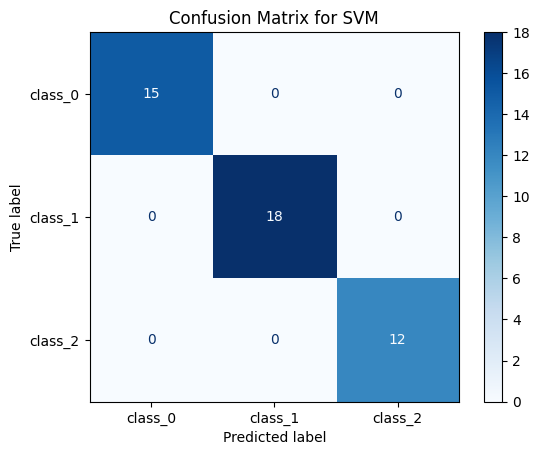

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for SVM')
plt.show()

In [ ]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=20
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=20)

In [ ]:
y_pred2 = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2, average='macro'))
print("Recall:", recall_score(y_test, y_pred2, average='macro'))
print("F1-score:", f1_score(y_test, y_pred2, average='macro'))

Accuracy: 0.9555555555555556
Precision: 0.9535256410256411
Recall: 0.9629629629629629
F1-score: 0.9563061353573689


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



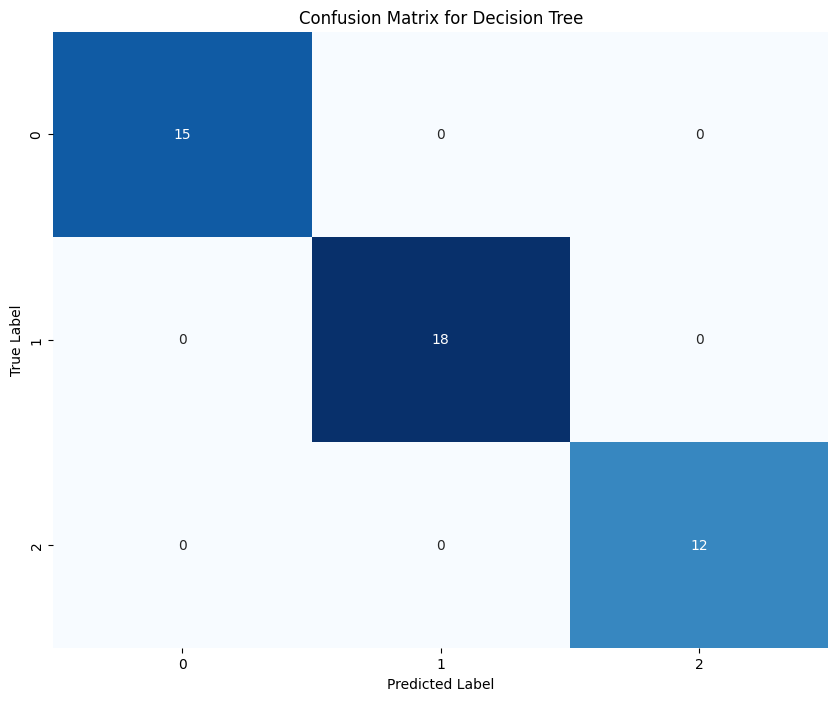

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Part B — Clustering + evaluation (20 marks)

Q4. KMeans on Wine Dataset + SSE (20)

Use Iris dataset for clustering.

1. Load Wine (X, y), but do clustering using X only (ignore labels for training).
2. Run KMeans with K=3.
3. Print
* SSE score

5. Make a 2D scatter plot using any two features (e.g., feature 0 vs feature 2) colored by cluster labels.

In [ ]:
# Hint: Covert the dataset to a pandas dataframe for Part B

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

In [ ]:
df=load_wine()

In [ ]:
X, y = df.data, df.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (178, 13)
y shape: (178,)


In [ ]:
# Run KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

# Get cluster labels and SSE
cluster_labels = kmeans.labels_
sse_score = kmeans.inertia_

# Print results
print("Number of clusters found:", len(np.unique(cluster_labels)))
print("SSE score:", sse_score)

Number of clusters found: 3
SSE score: 2370689.6867829696


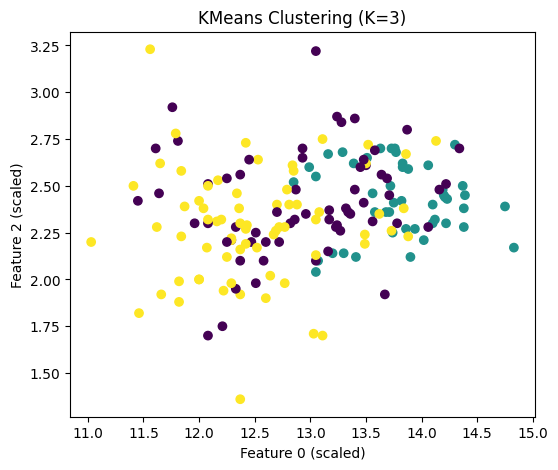

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 2],
            c=kmeans.labels_, cmap='viridis')

plt.xlabel("Feature 0 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("KMeans Clustering (K=3)")
plt.show()

# Part C - Submission (10 marks)
Submit notebook as: Lab5_Name_ID_Section.ipynb

Notebook must run from top to bottom without errors.